In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from collections import defaultdict 
import ast

sys.path.append(os.path.join(os.getcwd(), '../symlie'))
sys.path.append(os.path.join(os.getcwd(), '..'))
from symlie.misc.viz import plot2d

from symlie.misc.utils_results import pivot, assert_columns_same, get_and_check_Ps, stringify_dict, aggregate_dataset, plot_best, return_table, plot_pivot
from symlie.misc.utils import print_nested_keys
from symlie.misc.wandb import update_results_df, get_inspect_df, get_inspectdev_df
from symlie.model.setup import load_P_pred

sys.path.append(os.path.join(os.getcwd(), '../sympdee/sympde/viz'))
from sympdee.sympde.viz.general_plots import savefig 

/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RELOAD_DF = False

store_dir = '../store'
df_path = os.path.join(store_dir, 'combi_show_dev.csv')

if RELOAD_DF:
    df = get_inspectdev_df(tags = ['combi_show_dev'])
    df.to_csv(df_path, index=False)
df = pd.read_csv(df_path)

# df = df[df['n_train'] > 10]
# df = df[df['net'] != 'EMLP']


In [3]:
datasets = {
    r'Sine 1D, $Z(7)$' : '../data/sine1d',
    r'$O(5)$ dataset (Finzi 2021)' : '../data/o5synth',
}

method_dict = {
    'train' : 'ELL',
    'analytic' : 'Analytic ELL',
    'vanilla' : 'Vanilla',
    'emlp' : 'EMLP (Finzi 2021)',
}

title_dict = {
    'bias' : 'With bias',
    'no_bias' : 'Without bias'

}

colors = {'Analytic ELL': 'C0', 'ELL': 'C1', 'Vanilla': 'C2', 'EMLP (Finzi 2021)': 'C3', 'LPSDA': 'C4'}

method_dict = defaultdict(lambda: None, method_dict)

    

In [4]:
d_datas = {}

for dataset, data_dir in datasets.items():
    d_data = df[df['data_dir'] == data_dir]
    d_data = d_data.reset_index(drop=True)

    d_data['method'] = d_data['tags'].apply(lambda x: ''.join([method_dict[x_i] for x_i in ast.literal_eval(x) if method_dict[x_i] is not None]))

    columns = ['test_loss_y', 'max_epochs', 'method', 'n_train', 'seed', 'lr', 'bias']
    cols_groupby = ['method', 'n_train']
    loss = 'test_loss_y'
    d_data = d_data[columns]
    d_data = d_data.rename(columns = {'Analytic' : 'Analytic ELL'})

    d_datas[dataset] = {}


    bias_keys = {True : 'bias', False : 'no_bias'}
    for bias_val, bias_key in bias_keys.items():
        d_bias = d_data[d_data['bias'] == bias_val]
        d_datas[dataset][bias_key] = {'d_raw' : d_bias}

        d_datas[dataset][bias_key]['lr'] = {}
        d_lrs = d_bias.groupby('lr')
        for lr, d_lr in d_lrs:
            d_datas[dataset][bias_key]['lr'][lr] = d_lr
        
        
        # ds_plots = {bias_key: {lr: d_lr for lr, d_lr in d_lrs[bias_key]} for bias_key in bias_keys}
        
        
        # d_lrs = {bias_key : ds[bias_key].groupby('lr') for bias_key in bias_keys}
        # ds_plots = {bias_key: {lr: d_lr for lr, d_lr in d_lrs[bias_key]} for bias_key in bias_keys}


print_nested_keys(d_datas)


Sine 1D, $Z(7)$
  bias
    d_raw
    lr
      0.001
      0.01
      0.1
  no_bias
    d_raw
    lr
      0.001
      0.01
      0.1
$O(5)$ dataset (Finzi 2021)
  bias
    d_raw
    lr
      0.001
      0.01
      0.1
  no_bias
    d_raw
    lr
      0.001
      0.01
      0.1


In [5]:
def get_df_best(d):
    stats_df = d.groupby(['method', 'n_train', 'lr']).agg({'test_loss_y': ['mean', 'std']}).reset_index()
    stats_df.columns = ['method', 'n_train', 'lr', 'mean_loss', 'std_dev']

    idx = stats_df.groupby(['method', 'n_train'])['mean_loss'].idxmin()
    get_df_best = stats_df.loc[idx].reset_index(drop=True)
    return get_df_best

for dataset, ds in d_datas.items():
    for bias_key, d in ds.items():
        d['d_best'] = get_df_best(d['d_raw'])

print_nested_keys(d_datas)

Sine 1D, $Z(7)$
  bias
    d_raw
    lr
      0.001
      0.01
      0.1
    d_best
  no_bias
    d_raw
    lr
      0.001
      0.01
      0.1
    d_best
$O(5)$ dataset (Finzi 2021)
  bias
    d_raw
    lr
      0.001
      0.01
      0.1
    d_best
  no_bias
    d_raw
    lr
      0.001
      0.01
      0.1
    d_best


In [7]:
def add_handles(ax, handles, labels):
    handles_ax, labels_ax = ax.get_legend_handles_labels()
    for handle, label in zip(handles_ax, labels_ax):
        if label not in labels:
            handles.append(handle)
            labels.append(label)
    return handles, labels

In [8]:
df_pde_runs = pd.read_csv(os.path.join('../sympdee/notebooks', 'df_runs.csv'))
df_pde_stats = df_pde_runs.groupby(['experiment_name', 'n_train']).agg({'test_loss_y': ['mean', 'std']})

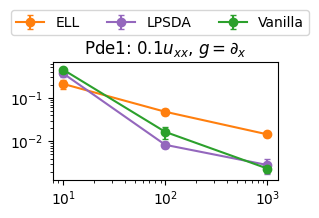

In [21]:
n_rows, n_cols = 1, 1
fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows), tight_layout = True, sharey = False)

ax = axs

handles, labels = [], []


ax.set_title(r'Pde1: $0.1 u_{xx}$, $g = \partial_x$')

for method, group in df_pde_stats.groupby('experiment_name'):
    ax.errorbar(group.index.get_level_values('n_train'), group['test_loss_y']['mean'], yerr=group['test_loss_y']['std'], label=method, capsize = 2, fmt='-o', color = colors[method])
ax.set_xscale('log')
ax.set_yscale('log')
handles, labels = add_handles(ax, handles, labels)


fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 1.1), ncol = len(handles))

savefig(fig, 'pde_results', '5-experiments',  format = 'pdf', bbox_inches = 'tight')



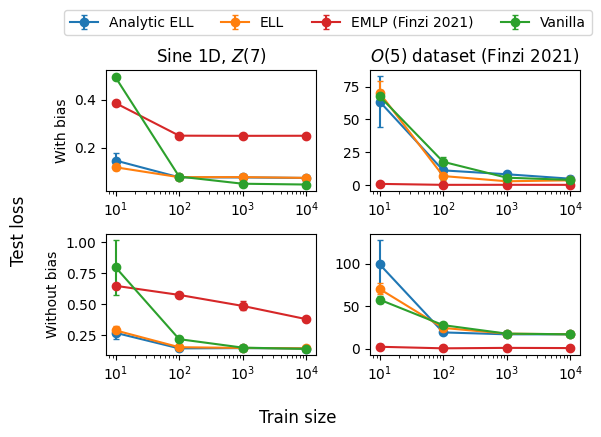

In [20]:
for ylog in [False]:
    n_cols= len(d_datas)
    n_rows = len(list(d_datas.values())[0])

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows), tight_layout = True, sharey = False)

    handles, labels = [], []

    for i, (dataset, ds) in enumerate(d_datas.items()):
        for j, (bias_key, d) in enumerate(ds.items()):
            ax = axs[j, i]
            d_best = d['d_best']
            
            for method, group in d_best.groupby('method'):
                ax.errorbar(group['n_train'], group['mean_loss'], yerr=group['std_dev'], fmt='-o', label=method, color=colors[method], capsize = 2)

            ax.set_xscale('log')
            if ylog:
                ax.set_yscale('log')

            if j == 0:
                ax.set_title(dataset)
            if i == 0:
                ax.set_ylabel(title_dict[bias_key])


            handles, labels = add_handles(ax, handles, labels)

    # ax = axs[0, 2]
    # ax.set_title(r'Pde1: $0.1 u_{xx}$, $g = \partial_x$')

    # for method, group in df_pde_stats.groupby('experiment_name'):
    #     ax.errorbar(group.index.get_level_values('n_train'), group['test_loss_y']['mean'], yerr=group['test_loss_y']['std'], label=method, capsize = 2, fmt='-o', color = colors[method])
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    # handles, labels = add_handles(ax, handles, labels)

    # ax = axs[1, 2]
    # ax.set_axis_off()


    fig.supxlabel('Train size')
    fig.supylabel('Test loss')
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 1.07), ncol = len(handles))

savefig(fig, 'implicit_results_best', '5-experiments', format = 'pdf', bbox_inches = 'tight')

/var/folders/_t/q2qhsxb97lj90dx67tklgrq40000gn/T/ipykernel_25408/2995787001.py:48: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 0.6)


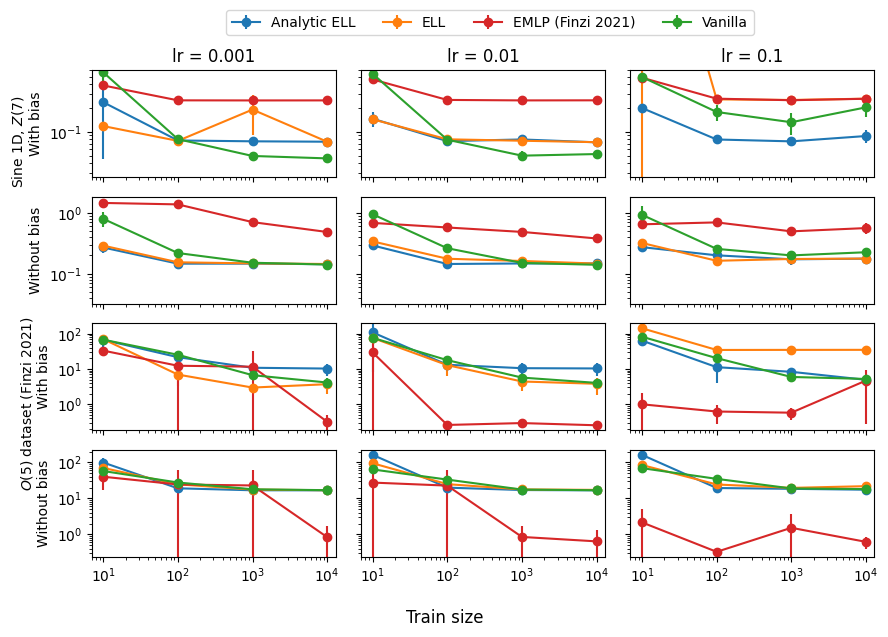

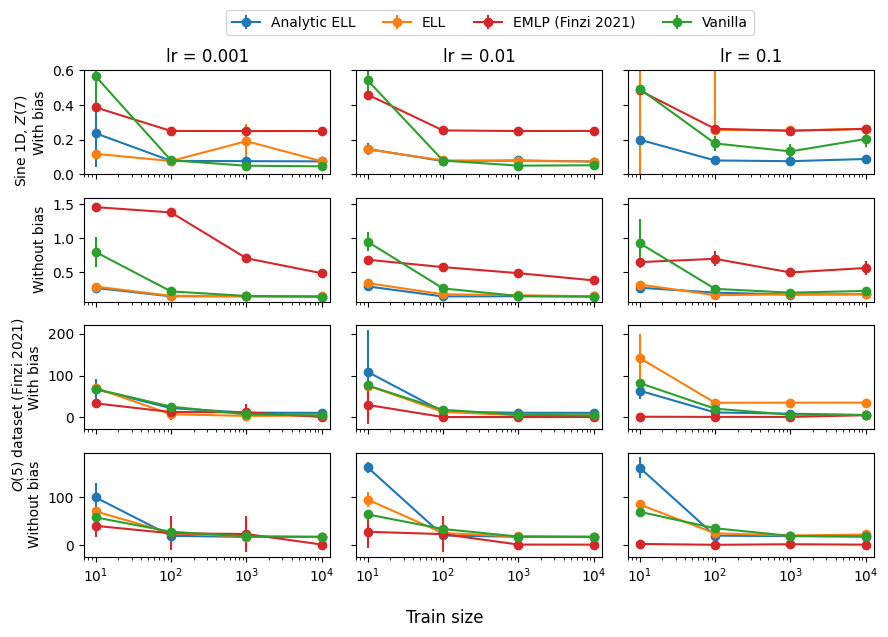

In [13]:
for ylog in [True, False]:
    n_cols = len(list(d_datas.values())[0]['bias']['lr'])
    n_rows = len(list(d_datas.values())[0]) * len(d_datas)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 1.5*n_rows), tight_layout = True, sharex = True, sharey = 'row')

    handles, labels = [], []

    row = 0
    for i, (dataset, ds) in enumerate(d_datas.items()):
        for j, (bias_key, d) in enumerate(ds.items()):
            for k, (lr, d_lr) in enumerate(d['lr'].items()):
                ax = axs[row, k]

                grouped = d_lr.groupby(['method', 'n_train'])
                means = grouped['test_loss_y'].mean().reset_index()
                std_devs = grouped['test_loss_y'].std().reset_index()

                # Get the corresponding standard deviations for the group
                for method, group in means.groupby('method'):
                    current_std_dev = std_devs[std_devs['method'] == method]['test_loss_y'].values
                    ax.errorbar(group['n_train'], group['test_loss_y'], yerr=current_std_dev, fmt='-o', label=method, color=colors[method], capsize=0)

                ax.set_xscale('log')
                if ylog: ax.set_yscale('log')

                if row == 0:
                    ax.set_title(f'lr = {lr}')

                if k == 0:
                    if row % 2 == 0:
                        ax.set_ylabel(f'{dataset}\t\t\n{title_dict[bias_key]}')
                    else:
                        ax.set_ylabel(title_dict[bias_key])

                handles_ax, labels_ax = ax.get_legend_handles_labels()
                for handle, label in zip(handles_ax, labels_ax):
                    if label not in labels:
                        handles.append(handle)
                        labels.append(label)

                ax.set_xlim(10**1*0.7, 10**4*1.3)

            row += 1


    ax = axs[0, 2]
    ax.set_ylim(0, 0.6)

    fig.supxlabel('Train size')
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 1.05), ncol = len(handles))
    fig.tight_layout()
    plt.show()

    savefig(fig, 'implicit_results_all' + ('_log' if ylog else ''), '5-experiments', bbox_inches = 'tight')
